In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.quantum_info import Statevector

In [ ]:


def build_feature_map(n_qubits=8):
    x = Parameter("x")
    qc = QuantumCircuit(n_qubits, name="FeatureMap")
    for q in range(n_qubits):
        qc.rx((q * x) / 2, q)
    return qc

def build_HEA(n_qubits=8, seed=1):
    depth = 5
    rng = np.random.default_rng(seed=seed)
    theta = rng.uniform(0, 2 * np.pi, size=(depth, n_qubits, 2))
    
    qc = QuantumCircuit(n_qubits, name="HEA")
    for i in range(depth):
        for q in range(n_qubits):
            qc.rx(theta[i, q, 0], q)
            qc.rz(theta[i, q, 1], q)
        for q in range(n_qubits - 1):
            qc.cx(q, q+1)
    return qc

def build_kernel_feature_map(n_qubits = 8):
    x = Parameter("x")
    qc = QuantumCircuit(n_qubits, name = "KernelMap")
    
    qc.compose(build_HEA(n_qubits), inplace = True)
    
    for q in range(n_qubits):
        qc.rx((q * x) / 2, q)
        
    qc.compose(build_HEA(n_qubits), inplace = True)
    
    for q in range(n_qubits):
        qc.rx((q * x) / 2, q)
    
    return qc
def teammate_quantum_kernel(x, y, n_qubits=8):
    """
    Evaluates the exact transition amplitude/fidelity between encoded 
    states x and y via fast Statevector simulation.
    """
    qc = build_kernel_feature_map(n_qubits)
    param_x = [p for p in qc.parameters if p.name == "x"][0]
    
    # Bind coordinates to independent feature circuits
    qc_x = qc.assign_parameters({param_x: x})
    qc_y = qc.assign_parameters({param_x: y})
    
    psi_x = Statevector.from_instruction(qc_x)
    psi_y = Statevector.from_instruction(qc_y)
    
    # Fidelity calculation: |<psi(y)|psi(x)>|^2
    return np.abs(np.vdot(psi_y.data, psi_x.data))**2

# Finite-Difference Derivative Operators for the Kernel
def dquantum_kernel_dx(x, y, eps=1e-5):
    """Computes the first-order partial derivative with respect to x."""
    return (teammate_quantum_kernel(x + eps, y) - teammate_quantum_kernel(x - eps, y)) / (2 * eps)

def d2quantum_kernel_dx2(x, y, eps=1e-5):
    """Computes the second-order partial derivative with respect to x."""
    return (
        teammate_quantum_kernel(x + eps, y)
        - 2 * teammate_quantum_kernel(x, y)
        + teammate_quantum_kernel(x - eps, y)
    ) / (eps ** 2)

# Kaj's solver
class MMRSolver:
    """
    Your third teammate's custom MMR class structure, which encapsulates 
    the parameter optimization pipeline and predictive matrix extensions.
    """
    def __init__(self, x_train, kernel):
        self.x_train = x_train
        self.Y = x_train.copy()
        self.kernel = kernel
        
        # Precompute the baseline Gram kernel matrix
        self.K = self.build_kernel_matrix()

    def build_kernel_matrix(self):
        return np.array([
            [self.kernel(xi, yj) for yj in self.Y]
            for xi in self.x_train
        ])

    def build_derivative_matrix(self, dkernel_dx):
        return np.array([
            [dkernel_dx(xi, yj) for yj in self.Y]
            for xi in self.x_train
        ])

    def model(self, alpha, b, K=None):
        if K is None:
            K = self.K
        return b + K @ alpha

    def solve(self, loss_function, method="BFGS"):
        init = np.zeros(len(self.Y) + 1)
        self.loss_history = []

        def wrapped_loss(params):
            value = loss_function(params)
            self.loss_history.append(value)
            return value

        result = minimize(wrapped_loss, init, method=method)
        self.alpha_opt = result.x[:-1]
        self.b_opt = result.x[-1]
        return result

    def predict(self, x_test):
        K_test = np.array([
            [self.kernel(xi, yj) for yj in self.Y]
            for xi in x_test
        ])
        return self.b_opt + K_test @ self.alpha_opt

# Generate grid elements
x_train = np.linspace(0, 5, 30)  # Collocation training checkpoints
x_test = np.linspace(0, 5, 300)

# Instantiate the MMR Solver utilizing your team's 8-qubit hardware kernel
solver = MMRSolver(x_train=x_train, kernel=teammate_quantum_kernel)

# Evaluate specific kernel matrix representations across the grid
Kx = solver.K
Kx_prime = solver.build_derivative_matrix(dquantum_kernel_dx)

# Define the global loss function utilizing the precomputed matrices
def loss(params):
    alpha = params[:-1]
    b = params[-1]

    # Evaluate expanding function values f(x) and analytical derivatives df(x)/dx
    f = b + Kx @ alpha
    df = Kx_prime @ alpha

    # Target standard Ordinary Differential Equation: df/dx + f(x) = sin(x)
    residual = df + f - np.sin(x_train)
    ode_loss = np.mean(residual**2)

    # Impose initial boundary constraints: f(0) = 0
    boundary_loss = (f[0] - 0.0)**2

    # Return total loss objective
    return ode_loss + boundary_loss

# Run optimization via Scipy minimize interface
result = solver.solve(loss_function=loss, method="BFGS")
print(f"MMR Classical BFGS Optimizer Success: {result.success}")
print(f"Final Convergence Residual Error: {result.fun:.8f}")

# Generate prediction trajectory 
qk_pred = solver.predict(x_test)
exact = 0.5 * (np.sin(x_test) - np.cos(x_test) + np.exp(-x_test))

# fig, ax = plt.subplots(1, 1, figsize=(14, 6))

# ax.plot(x_test, exact, 'k-', label='Exact Analytical Solution', linewidth=2.5)
# ax.plot(x_test, qk_pred, 'b--', label="MMR Solver via Friend's 8-Qubit HEA Kernel", linewidth=2)
# ax.scatter(x_train, np.zeros_like(x_train), color='red', marker='x', s=100, label='Grid Collocation Nodes', zorder=3)

# ax.set_title("ODE Integration Framework via Mixed Model Regression (MMR)", fontsize=14, fontweight='bold', pad=15)
# ax.set_xlabel("Domain Grid x", fontsize=12)
# ax.set_ylabel("f(x)", fontsize=12)
# ax.legend(loc="best", fontsize=11)
# ax.grid(True, linestyle='--', alpha=0.6)

# plt.tight_layout()
# plt.show()

MMR Classical BFGS Optimizer Success: True
Final Convergence Residual Error: 0.00000009


NameError: name 'x_test' is not defined

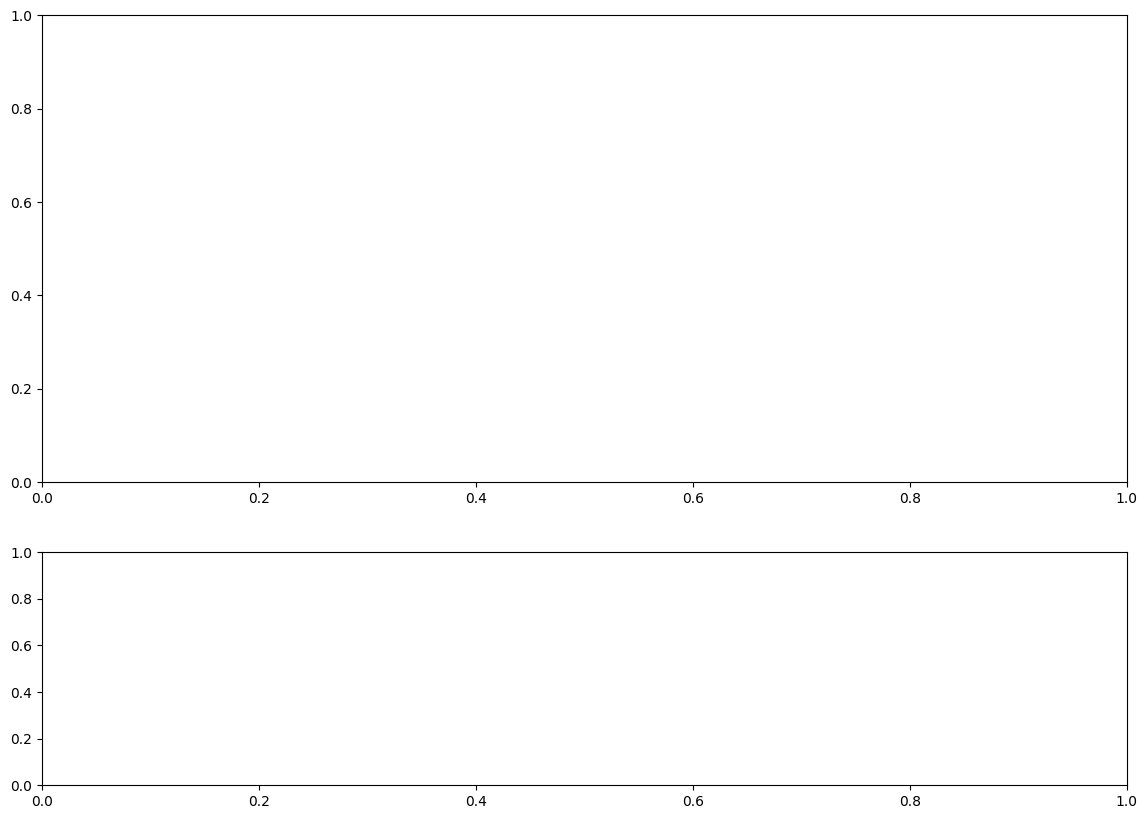

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1.5]})

ax1.plot(x_test, exact, 'k-', label='Exact Analytical Solution', linewidth=2.5)
ax1.plot(x_test, qk_pred, 'b--', label="MMR Solver via Friend's 8-Qubit HEA Kernel", linewidth=2)
# ax1.scatter(x_train, np.zeros_like(x_train), color='red', marker='x', s=100, label='Grid Collocation Nodes', zorder=3)

ax1.set_title("ODE Integration Framework via Mixed Model Regression (MMR)", fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel("Domain Grid x", fontsize=12)
ax1.set_ylabel("f(x)", fontsize=12)
ax1.legend(loc="best", fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.6)

abs_error = np.abs(exact - qk_pred)

ax2.plot(x_test, abs_error, 'r-', linewidth=2)
ax2.fill_between(x_test, abs_error, alpha=0.2, color='red')

ax2.set_title("Absolute Error", fontsize=13, fontweight='bold', pad=10)
ax2.set_xlabel("Domain Grid x", fontsize=12)
ax2.set_ylabel("Absolute Error", fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.set_yscale('log')  # log scale often clearest for error plots

plt.tight_layout(pad=3.0)
plt.show()